# Answers - Spotiflow

### First run the main notebook

In [1]:
%%capture
%run './03_spotiflow.ipynb'

## Exercise: How many spots does Spotiflow find outside the nuclei?

We already have `spot_label`, which is 0 for every spot that is not inside a nucleus.

In [2]:
outside = spot_label == 0
print(f"{np.sum(outside)} of {len(points)} spots are outside the nuclei")

282 of 1709 spots are outside the nuclei


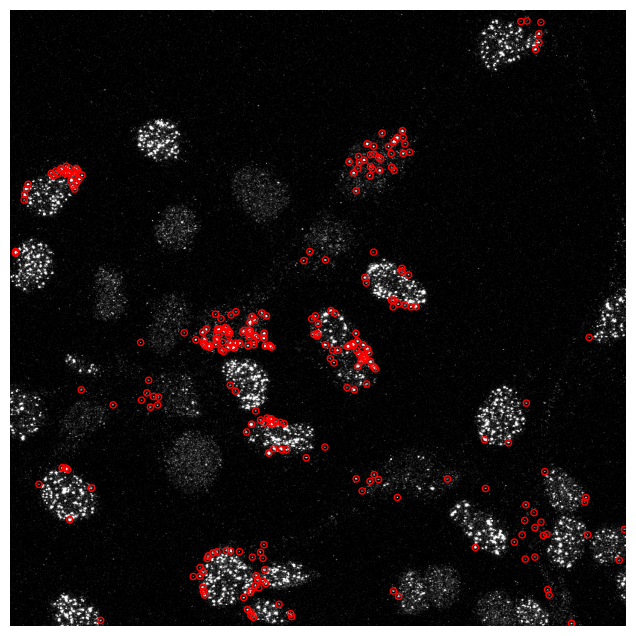

In [3]:
_ = plt.figure(figsize=(8, 8))
_ = plt.imshow(img_foci, cmap="gray", vmax=np.percentile(img_foci, 99))
_ = plt.scatter(points[outside, 1], points[outside, 0], s=20, facecolors="none", edgecolors="red")
_ = plt.axis("off")

Two different things show up in that plot. Some spots lie just outside the edge of a
nucleus, where the Cellpose mask is slightly smaller than the nucleus. But the larger
group sits on nuclei that Cellpose did not find at all: every focus in such a nucleus
counts as being outside.

So this plot says as much about the segmentation as about the spot detection. A nucleus
that is missed does not just lower the number of nuclei, it also removes all of its foci
from the analysis. It is worth checking this before drawing conclusions from the counts.

## Exercise: What does the detection threshold change?

A higher `prob_thresh` keeps only the spots the model is more confident about.

In [4]:
for thresh in [0.3, 0.5, 0.7]:
    points_thresh, _ = model_spots.predict(img_foci, prob_thresh=thresh, verbose=False)
    print(f"prob_thresh {thresh}: {len(points_thresh)} spots")

prob_thresh 0.3: 2390 spots
prob_thresh 0.5: 1709 spots
prob_thresh 0.7: 1331 spots


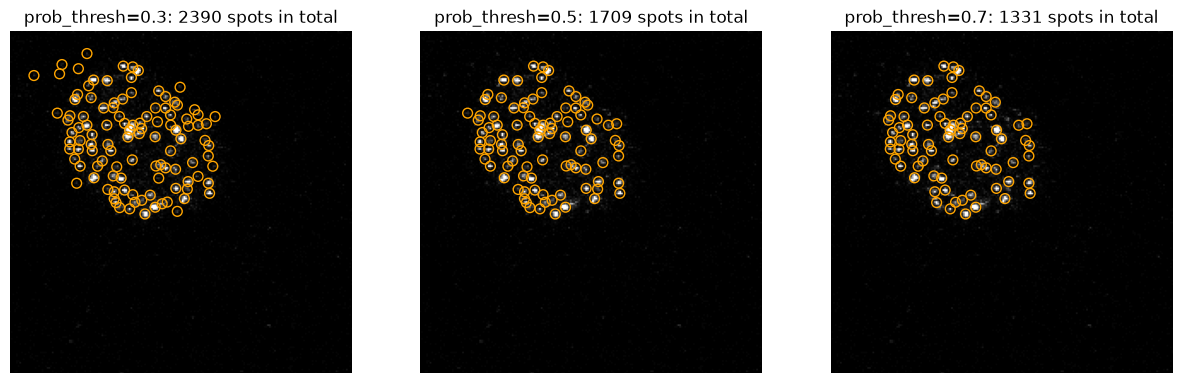

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, thresh in zip(axs, [0.3, 0.5, 0.7]):
    points_thresh, _ = model_spots.predict(img_foci, prob_thresh=thresh, verbose=False)
    _ = ax.imshow(img_foci, cmap="gray", vmax=np.percentile(img_foci, 99.8))
    _ = ax.scatter(points_thresh[:, 1], points_thresh[:, 0], s=50, facecolors="none", edgecolors="orange")
    _ = ax.set_xlim(x0, x0 + size)
    _ = ax.set_ylim(y0 + size, y0)
    _ = ax.set_title(f"prob_thresh={thresh}: {len(points_thresh)} spots in total")
    _ = ax.axis("off")

The spots that appear and disappear are the dim ones. The bright, clearly separated foci
are found at every threshold.

If you compare conditions, use the same threshold everywhere: the control images are
dimmer, so a threshold that is too high removes more spots there than in the irradiated
images.

## Bonus exercise: Nuclei on the edge of the image

In [6]:
import skimage as sk

def count_foci_per_nucleus(path):
    """Return the number of foci in each nucleus that does not touch the border."""

    img = tiff.imread(path)
    points, _ = model_spots.predict(img[0, :, :], verbose=False)
    masks, _, _ = model_nuc.eval(img[1, :, :], channels=[0, 0], diameter=80)

    # Remove the nuclei that touch the border, and number the others 1, 2, 3, ... again
    masks = sk.segmentation.clear_border(masks)
    masks, _, _ = sk.segmentation.relabel_sequential(masks)

    spot_y = np.round(points[:, 0]).astype(int)
    spot_x = np.round(points[:, 1]).astype(int)
    counts = np.bincount(masks[spot_y, spot_x], minlength=masks.max() + 1)

    return counts[1:]

results_no_border = []
for path in files:
    condition = "IR" if "IR" in path else "control"
    for n_foci in count_foci_per_nucleus(path):
        results_no_border.append({"file": path, "condition": condition, "foci": n_foci})

results_no_border = pd.DataFrame(results_no_border)
results_no_border.groupby("condition")["foci"].agg(["count", "mean", "median"])

,count,mean,median
condition,,,
IR,54,39.555556,36.5
control,87,13.160920,13.0


Without the border nuclei we keep 54 of the 69 irradiated nuclei and 87 of the 101 control
nuclei. The mean number of foci per irradiated nucleus goes up from about 37 to 40: the
nuclei that were cut off by the border did indeed have less foci. 

Note the `relabel_sequential()` step. `clear_border()` sets the removed nuclei to 0 but
keeps the numbers of the others, so there are gaps (1, 2, 5, 6, ...). `np.bincount()` would
then report 0 foci for the missing numbers, and those zeros would pull the mean down again.